In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools

cnot = pd.read_csv('data/data_cnot_fidelity_3ncut.txt')
# df = pd.DataFrame(p, columns=['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1',
#                                    'detune_2', 'f_200_select', 'f_1000_False',  ])
# df.to_csv('data/data_cnot_fidelity_3ncut.txt', sep=',', index=False, header=True)

In [12]:
cnot = pd.read_csv('data/data_cnot_fidelity_3ncut.txt')
x0_vec = cnot[['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2'
                    ]].to_numpy()[1::5, :]
x0_vec

array([[ 4.00167660e+01,  1.04833000e-01,  4.99140000e-02,
        -3.04960000e-02, -2.86930000e-02],
       [ 9.00048820e+01,  5.71330000e-02,  3.09090000e-02,
        -1.33630000e-02, -1.32500000e-02],
       [ 1.40005331e+02,  4.13940000e-02,  2.57940000e-02,
        -1.02060000e-02, -9.61200000e-03],
       [ 1.89997344e+02,  3.09150000e-02,  1.97550000e-02,
        -6.19400000e-03, -5.84800000e-03],
       [ 2.39989977e+02,  2.39570000e-02,  1.53870000e-02,
        -3.74400000e-03, -3.54600000e-03],
       [ 2.90001675e+02,  1.95750000e-02,  1.25200000e-02,
        -2.47000000e-03, -2.35300000e-03],
       [ 3.40006300e+02,  1.66180000e-02,  1.06080000e-02,
        -1.77400000e-03, -1.69000000e-03]])

In [2]:
tg3 = [30, 180, 330]
f_200_100us = np.array([-0.30825174, -2.3734399, -2.9963803 ,])
f_50_10us = np.array([-0.30734154, -2.15333588, -2.43233029 ,])
f_9_2us = np.array([-0.30336583, -1.69986675, -1.77383625 ,])


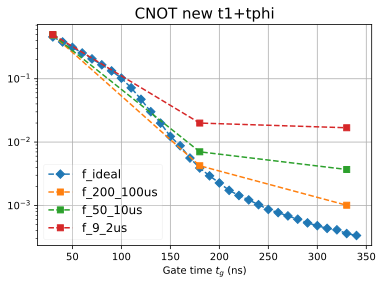

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cnot['tg'], 10**cnot['f_1000_False'], 'D--',  label=r'f_ideal')
ax.plot(tg3, 10**f_200_100us, 's--',  label=r'f_200_100us')
ax.plot(tg3, 10**f_50_10us, 's--',  label=r'f_50_10us')
ax.plot(tg3, 10**f_9_2us, 's--',  label=r'f_9_2us')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CNOT new t1+tphi', fontsize=15)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
f_100_select = np.array([
-0.29959668, -0.37641895, -0.47861723, -0.60666134, -0.72551985,
-0.83960942, -0.92840786, -1.01425332, -1.15043255, -1.33161182,
-1.55658826, -1.77091185, -1.92250542, -2.06536472, -2.2534972,
-2.41437864, -2.54093738, -2.65215528, -2.764731, -2.84939887,
-2.91926708, -2.99295654, -3.06882559, -3.12323214, -3.16987398,
-3.22965957, -3.28333998, -3.32459057, -3.36338371, -3.40576638,
-3.45048865, -3.48626832
])
f_70_10_select = np.array([
-0.31869766, -0.41276724, -0.52474891, -0.65542015 ,
-0.75815145, -0.86016009, -0.93202173, -1.01565992 ,
-1.15477611, -1.33865867, -1.5652048, -1.77941355 ,
-1.92770876, -2.07314954, -2.26061506, -2.41947799 ,
-2.54886798, -2.66136648, -2.77444726, -2.85947508 ,
-2.92755365, -2.99940204, -3.07863151, -3.132642 ,
-3.17560734, -3.23955047, -3.29171214, -3.33322871 ,
-3.37311664, -3.41560188, -3.45985248, -3.49474837 ,
])
f_60_5_select = np.array([
-0.306627, -0.41589425, -0.54477106, -0.67289964 ,
-0.76219676, -0.85913109, -0.92965729, -1.01673113 ,
-1.16001318, -1.34832389, -1.58228214, -1.79568155 ,
-1.93636921, -2.08416585, -2.27868945, -2.43740799 ,
-2.5651214, -2.67723772, -2.78801457, -2.8691916 ,
-2.93214382, -3.00174254, -3.07863262, -3.12890229 ,
-3.16832707, -3.23184584, -3.27962425, -3.32024053 ,
-3.35920696, -3.39815215, -3.44177596, -3.47457385 ,
])
f_55_5_select = np.array([
-0.30837105, -0.41915456, -0.54748191, -0.67306385 ,
-0.76053762, -0.85632286, -0.92636722, -1.01368202 ,
-1.15704733, -1.3451509, -1.57841328, -1.79033564 ,
-1.92947956, -2.07880109, -2.27285841, -2.43016406 ,
-2.559748, -2.6736226, -2.78525417, -2.86702638 ,
-2.92928646, -2.99885625, -3.07743822, -3.12760541 ,
-3.16576048, -3.231448, -3.27816315, -3.31975139 ,
-3.35914688, -3.39717795, -3.44178535, -3.47419315 ,
]) # good 1-55, 90-95

f_50_5_5_select = np.array([
-0.34544633, -0.47147129, -0.57136706, -0.66294394 ,
-0.71893623, -0.80381433, -0.91769914, -1.06730216 ,
-1.24750487, -1.44128782, -1.65980794, -1.8052205 ,
-1.94795074, -2.14981459, -2.38689566, -2.52843429 ,
-2.64903289, -2.77143836, -2.8758316, -2.94040384 ,
-3.00538877, -3.07454615, -3.1380988, -3.18215436 ,
-3.2243892, -3.2819437, -3.32474791, -3.36081687 ,
-3.3992683, -3.43781313, -3.47444572, -3.50685189 ,
]) # bad 1-50, 55-60, 90-95

f_45_5_5_select = np.array([
-0.17857883, -0.27648875, -0.4067056, -0.57836668 ,
-0.68298671, -0.80523124, -0.96865642, -1.1341046 ,
-1.30302491, -1.47019671, -1.67661664, -1.8543327 ,
-2.09208523, -2.36195592, -2.73422916, -2.93521297 ,
-3.07186551, -3.20431466, -3.31842124, -3.33857553 ,
-3.38328088, -3.4570678, -3.44457806, -3.46602353 ,
-3.50120979, -3.51102007, -3.54352973, -3.58490524 ,
-3.59361497, -3.61213942, -3.64687299, -3.67041503 ,
]) # bad 1-45, 50-55, 90-95

f_45_5_5_select = np.array([
-0.17857883, -0.27648875, -0.4067056, -0.57836668 ,
-0.68298671, -0.80523124, -0.96865642, -1.1341046 ,
-1.30302491, -1.47019671, -1.67661664, -1.8543327 ,
-2.09208523, -2.36195592, -2.73422916, -2.93521297 ,
-3.07186551, -3.20431466, -3.31842124, -3.33857553 ,
-3.38328088, -3.4570678, -3.44457806, -3.46602353 ,
-3.50120979, -3.51102007, -3.54352973, -3.58490524 ,
-3.59361497, -3.61213942, -3.64687299, -3.67041503 ,
]) # very bad 1-40, 45-50, 50-55, 90-95

f_35_15_5_select = np.array([
-0.34558177, -0.44207095, -0.54889192, -0.61727743 ,
-0.70468841, -0.8387977, -0.98575536, -1.09235409 ,
-1.20940826, -1.34572952, -1.53303234, -1.73160455 ,
-1.94510733, -2.13517018, -2.32852417, -2.45251975 ,
-2.59727094, -2.73060975, -2.82257919, -2.89518468 ,
-2.969494, -3.04237656, -3.09912435, -3.14615209 ,
-3.20141997, -3.25528915, -3.28892002, -3.33774232 ,
-3.38280318, -3.39910466, -3.45214782, -3.48561027 ,
]) # middle 1-40, 45-50, 50-55, 90-95


f_50_pop = np.array([
-0.31900143, -0.41656879, -0.52578841, -0.66481122 ,
-0.76665432, -0.86690743, -0.93998337, -1.02960161 ,
-1.17891946, -1.37583374, -1.62142635, -1.83881464 ,
-1.97444783, -2.12611058, -2.32698949, -2.48494204 ,
-2.61443787, -2.73110177, -2.84454296, -2.92137775 ,
-2.98431745, -3.04944368, -3.13312377, -3.1810462 ,
-3.21840684, -3.28698242, -3.33468825, -3.36773666 ,
-3.41224035, -3.45297366, -3.49326323, -3.52532598 ,
]) # mid

f_60_pop = np.array([
-0.31719883, -0.40016521, -0.50208111, -0.63879903 ,
-0.74148078, -0.83705793, -0.90106169, -0.97968072 ,
-1.10656443, -1.26843636, -1.44018235, -1.61450178 ,
-1.76763417, -1.95107929, -2.12933983, -2.31643958 ,
-2.48818518, -2.6360821, -2.7628383, -2.85357775 ,
-2.92042237, -2.98967798, -3.07660205, -3.12884377 ,
-3.16820456, -3.24028486, -3.28773092, -3.32892704 ,
-3.37536165, -3.41175827, -3.45997253, -3.49258259 ,
]) # mid

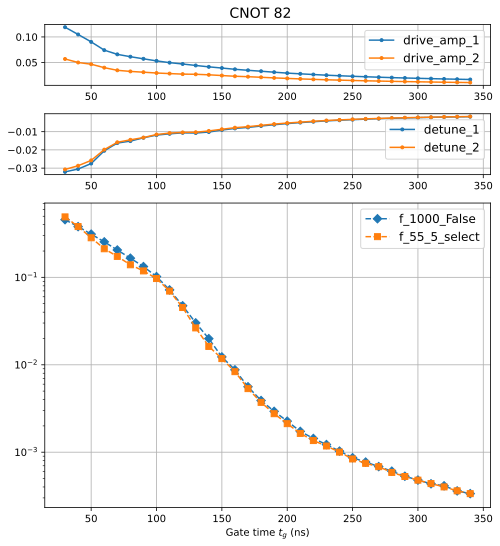

In [ ]:
fig, ax = plt.subplots(figsize=(8,8), nrows=3, gridspec_kw={'height_ratios': [1, 1, 5]})
fig.suptitle('CNOT 82', fontsize=14)
fig.subplots_adjust(top=0.95)
ax[0].plot(cnot['tg'], cnot['drive_amp_1'], '.-',  label=r'drive_amp_1')
ax[0].plot(cnot['tg'], cnot['drive_amp_2'], '.-',  label=r'drive_amp_2')
ax[1].plot(cnot['tg'], cnot['detune_1'], '.-',  label=r'detune_1')
ax[1].plot(cnot['tg'], cnot['detune_2'], '.-',  label=r'detune_2')
# ax[2].plot(cnot['tg'], 10**cnot['f_200_select'], '.-',  label=r'f_200_select')
ax[2].plot(cnot['tg'], 10**cnot['f_1000_False'], 'D--',  label=r'f_1000_False')
# ax[2].plot(cnot['tg'], 10**f_100_select, 'D--',  label=r'f_100_select')
# ax[2].plot(cnot['tg'], 10**f_70_10_select, '.--',  label=r'f_70_10_select')
# ax[2].plot(cnot['tg'], 10**f_70_select, 'x--',  label=r'f_70_select')
# ax[2].plot(cnot['tg'], 10**f_60_5_select, 's--',  label=r'f_60_5_select')
# ax[2].plot(cnot['tg'], 10**f_55_5_select, 's--',  label=r'f_55_5_select')
# ax[2].plot(cnot['tg'], 10**f_50_5_5_select, 'x--',  label=r'f_50_5_5_select')
# ax[2].plot(cnot['tg'], 10**f_45_5_5_select, 'x--',  label=r'f_45_5_5_select')
# ax[2].plot(cnot['tg'], 10**f_35_15_5_select, 'x--',  label=r'f_35_15_5_select')
# ax[2].plot(cnot['tg'], 10**f_50_pop, '+--',  label=r'f_50_pop')
# ax[2].plot(cnot['tg'], 10**f_60_pop, 'x--',  label=r'f_60_pop')
plt.xlabel('Gate time $t_g$ (ns)')
ax[2].set_yscale('log')
for i in range(3):
    ax[i].legend(loc='best', fontsize=12)
    ax[i].grid()